🚀 Generating EDA Assets for Section 4.2...
✅ Loaded cleaned_retail_data.csv from storage.

📋 TABLE: Descriptive Statistics (Copy for Section 4.2.2)
                count   mean     std  min   25%    50%    75%       max  Skewness   Kurtosis
Quantity     779390.0  13.49  145.86  1.0  2.00   6.00  12.00   80995.0    401.11  208828.82
UnitPrice    779390.0   3.21   29.41  0.0  1.25   1.95   3.75   10953.5    245.92   74553.73
TotalAmount  779390.0  22.28  227.40  0.0  4.95  12.48  19.80  168469.6    579.83  404510.49


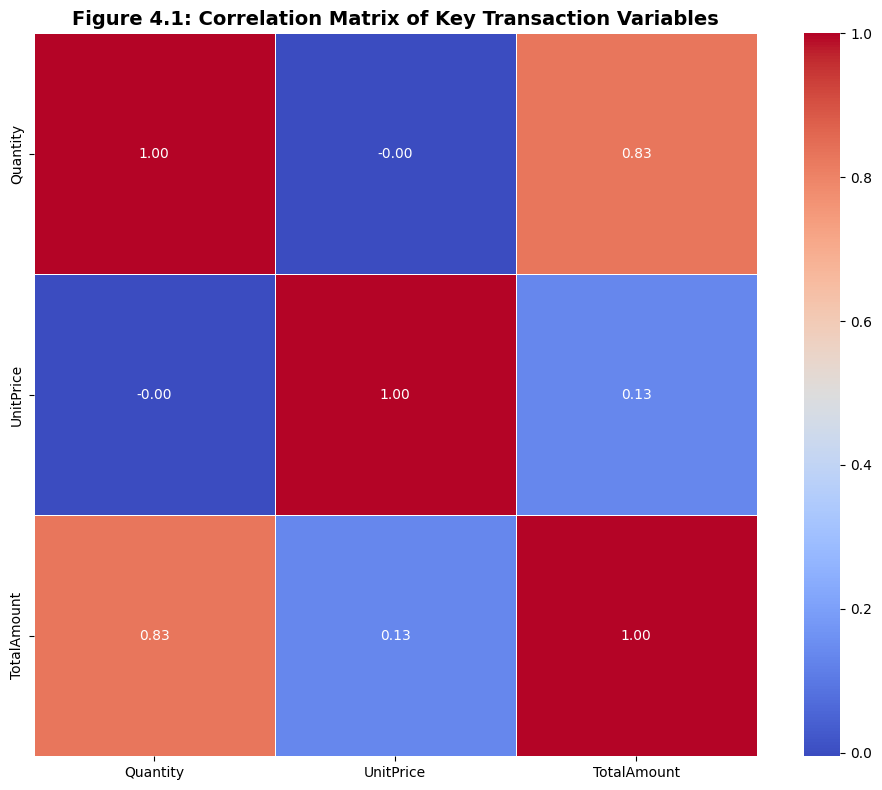

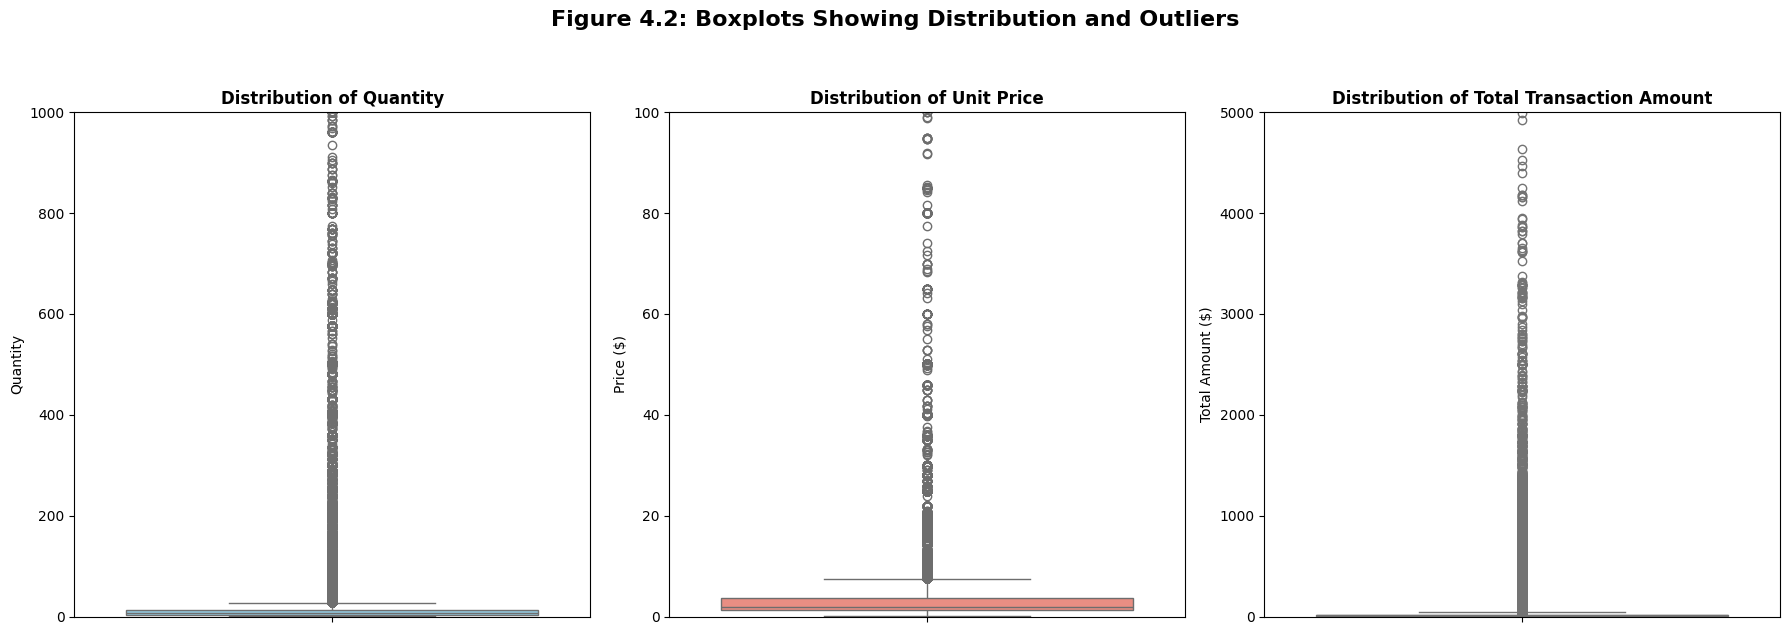

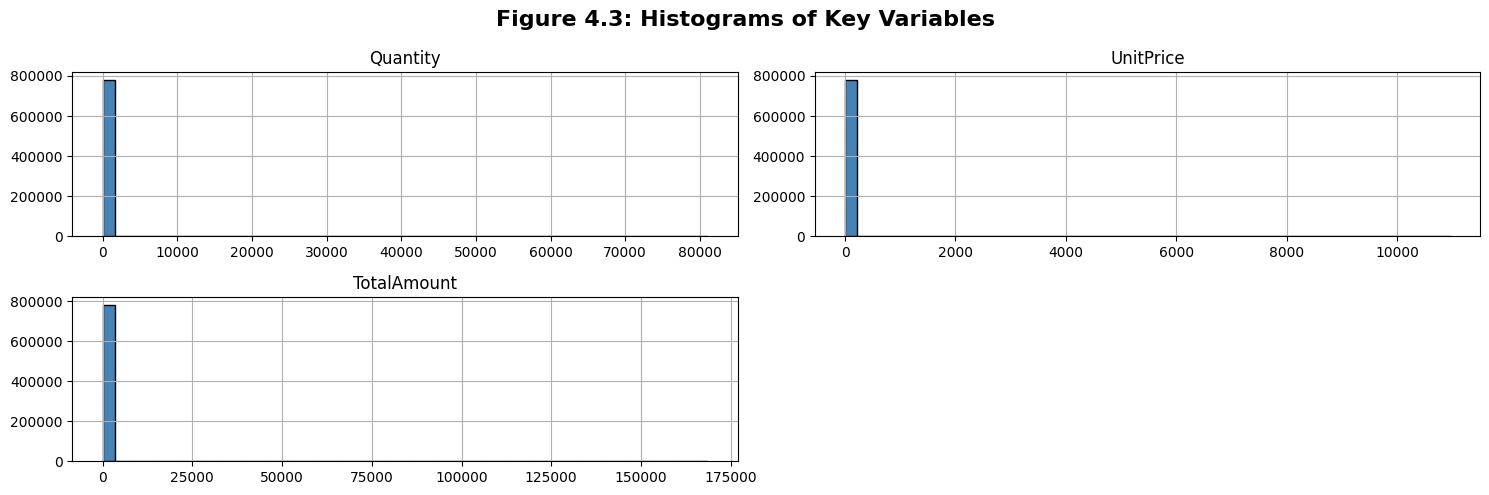


💾 EDA Assets Generated!
📝 INSTRUCTIONS FOR DISSERTATION:
1. Copy the 'Descriptive Statistics' table text into Section 4.2.2.
2. Save the Heatmap as Figure 4.1.
3. Save the Boxplots panel as Figure 4.2.
4. Save the Histograms as Figure 4.3 (optional).
5. In the text, explain that high skewness/kurtosis justified the outlier removal in Chapter 3.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("🚀 Generating EDA Assets for Section 4.2...")

# 1. LOAD DATA
try:
    df = pd.read_csv('cleaned_retail_data.csv')
    print("✅ Loaded cleaned_retail_data.csv from storage.")
except FileNotFoundError:
    print("📂 File not found in storage. Please upload 'cleaned_retail_data.csv':")
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(fname)
    # Save it back to storage for consistency
    df.to_csv('cleaned_retail_data.csv', index=False)

# Rename 'Price' to 'UnitPrice' for consistency with the rest of the code
if 'Price' in df.columns and 'UnitPrice' not in df.columns:
    df.rename(columns={'Price': 'UnitPrice'}, inplace=True)

# Ensure Date is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalAmount if missing
if 'TotalAmount' not in df.columns:
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Select Numerical Columns for EDA
num_cols = ['Quantity', 'UnitPrice', 'TotalAmount']
# Filter out extreme outliers for better visualization (optional, but makes plots readable)
# We will plot the full data but cap the y-axis for visibility if needed
df_eda = df[num_cols].copy()

# ==========================================
# 2. KEY DESCRIPTIVE STATISTICS (Table 4.1)
# ==========================================
desc_stats = df_eda.describe().transpose()
desc_stats['Skewness'] = df_eda.skew()
desc_stats['Kurtosis'] = df_eda.kurt()

print("\n📋 TABLE: Descriptive Statistics (Copy for Section 4.2.2)")
print(desc_stats.round(2).to_string())

# ==========================================
# 3. CORRELATION MATRIX (Heatmap)
# ==========================================
plt.figure(figsize=(10, 8))
corr_matrix = df_eda.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, square=True)
plt.title('Figure 4.1: Correlation Matrix of Key Transaction Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 4. BOX PLOTS (Distribution & Outliers)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot 1: Quantity
sns.boxplot(y=df_eda['Quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Quantity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantity')
# Cap y-axis for visibility if outliers are huge
if df_eda['Quantity'].max() > 1000:
    axes[0].set_ylim(0, 1000)

# Boxplot 2: UnitPrice
sns.boxplot(y=df_eda['UnitPrice'], ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Unit Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price ($)')
if df_eda['UnitPrice'].max() > 100:
    axes[1].set_ylim(0, 100)

# Boxplot 3: TotalAmount
sns.boxplot(y=df_eda['TotalAmount'], ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Total Transaction Amount', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Total Amount ($)')
if df_eda['TotalAmount'].max() > 5000:
    axes[2].set_ylim(0, 5000)

plt.suptitle('Figure 4.2: Boxplots Showing Distribution and Outliers', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ==========================================
# 5. HISTOGRAMS (Optional but good for EDA)
# ==========================================
df_eda.hist(bins=50, figsize=(15, 5), color='steelblue', edgecolor='black')
plt.suptitle('Figure 4.3: Histograms of Key Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💾 EDA Assets Generated!")
print("📝 INSTRUCTIONS FOR DISSERTATION:")
print("1. Copy the 'Descriptive Statistics' table text into Section 4.2.2.")
print("2. Save the Heatmap as Figure 4.1.")
print("3. Save the Boxplots panel as Figure 4.2.")
print("4. Save the Histograms as Figure 4.3 (optional).")
print("5. In the text, explain that high skewness/kurtosis justified the outlier removal in Chapter 3.")